# MNIST Digit Classifier 


## 1 — Imports

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from time import strftime
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Reproducibility
np.random.seed(888)
tf.random.set_seed(404)

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')

TensorFlow version : 2.20.0
Keras version      : 3.13.2


## 2 — Constants

In [5]:
# ── Data paths ──────────────────────────────────────────────────────────────
X_TRAIN_PATH = 'MNIST/digit_xtrain.csv'
X_TEST_PATH  = 'MNIST/digit_xtest.csv'
Y_TRAIN_PATH = 'MNIST/digit_ytrain.csv'
Y_TEST_PATH  = 'MNIST/digit_ytest.csv'

# ── Logging ──────────────────────────────────────────────────────────────────
LOGGING_PATH = 'tensorboard_mnist_digit_logs/'

# ── Dataset dimensions ───────────────────────────────────────────────────────
NR_CLASSES     = 10
VALIDATION_SIZE = 10000
IMAGE_WIDTH    = 28
IMAGE_HEIGHT   = 28
CHANNELS       = 1
TOTAL_INPUTS   = IMAGE_WIDTH * IMAGE_HEIGHT * CHANNELS   # 784

# ── Hyperparameters ──────────────────────────────────────────────────────────
NR_EPOCHS     = 50
LEARNING_RATE = 0.001
BATCH_SIZE    = 1000
N_HIDDEN1     = 512
N_HIDDEN2     = 64
DROPOUT_RATE  = 0.2   # fraction of units to DROP (keep_prob was 0.8  =>  drop = 0.2)

## 3 — Load the Data

In [6]:
%%time
y_train_all = np.loadtxt(Y_TRAIN_PATH, delimiter=',', dtype=int)
print('y_train_all shape:', y_train_all.shape)

y_train_all shape: (60000,)
CPU times: total: 15.6 ms
Wall time: 12.5 ms


In [7]:
%%time
x_train_all = np.loadtxt(X_TRAIN_PATH, delimiter=',', dtype=int)
print('x_train_all shape:', x_train_all.shape)

x_train_all shape: (60000, 784)
CPU times: total: 5.91 s
Wall time: 5.94 s


In [8]:
%%time
x_test = np.loadtxt(X_TEST_PATH, delimiter=',', dtype=int)
y_test = np.loadtxt(Y_TEST_PATH, delimiter=',', dtype=int)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_test shape: (10000, 784)
y_test shape: (10000,)
CPU times: total: 969 ms
Wall time: 981 ms


## 4 — Explore the Data

In [9]:
print('x_train_all:', x_train_all.shape)  # (60000, 784)
print('y_train_all:', y_train_all.shape)  # (60000,)
print('x_test     :', x_test.shape)       # (10000, 784)
print('y_test     :', y_test.shape)       # (10000,)
print('First 5 labels:', y_train_all[:5])

x_train_all: (60000, 784)
y_train_all: (60000,)
x_test     : (10000, 784)
y_test     : (10000,)
First 5 labels: [5 0 4 1 9]


## 5 — Pre-Processing

In [ ]:
# ── Normalise pixel values to [0, 1] ────────────────────────────────────────
x_train_all = x_train_all / 255.0
x_test      = x_test      / 255.0

# ── One-hot encode labels ────────────────────────────────────────────────────
y_train_all_hot = keras.utils.to_categorical(y_train_all, num_classes=NR_CLASSES)
y_test_hot      = keras.utils.to_categorical(y_test,      num_classes=NR_CLASSES)

print('y_train_all (one-hot):', y_train_all_hot.shape)  # (60000, 10)
print('y_test      (one-hot):', y_test_hot.shape)        # (10000, 10)

y_train_all (one-hot): (60000, 10)
y_test      (one-hot): (10000, 10)


### Split off a Validation Set

In [11]:
x_val   = x_train_all[:VALIDATION_SIZE]
y_val   = y_train_all_hot[:VALIDATION_SIZE]

x_train = x_train_all[VALIDATION_SIZE:]
y_train = y_train_all_hot[VALIDATION_SIZE:]

# Integer labels (needed for visualizations later)
y_train_int = y_train_all[VALIDATION_SIZE:]
y_test_int  = y_test

print('Training set  :', x_train.shape, y_train.shape)
print('Validation set:', x_val.shape,   y_val.shape)
print('Test set      :', x_test.shape,  y_test_hot.shape)

Training set  : (50000, 784) (50000, 10)
Validation set: (10000, 784) (10000, 10)
Test set      : (10000, 784) (10000, 10)


## 6 — Build the Model

Architecture: **Input(784) -> Dense(512, ReLU) -> Dropout(0.2) -> Dense(64, ReLU) -> Dense(10, Softmax)**


In [12]:
model = keras.Sequential([
    keras.Input(shape=(TOTAL_INPUTS,), name='input'),
    keras.layers.Dense(N_HIDDEN1, activation='relu',     name='layer_1'),
    keras.layers.Dropout(DROPOUT_RATE,                   name='dropout_layer'),
    keras.layers.Dense(N_HIDDEN2, activation='relu',     name='layer_2'),
    keras.layers.Dense(NR_CLASSES, activation='softmax', name='output'),
], name='MLP_Model')

model.summary()

Model: "MLP_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,402 (1.66 MB)

 Trainable params: 435,402 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

## 7 — Compile the Model

Replaces the old `tf.train.AdamOptimizer` + manual loss + accuracy ops with a single `model.compile()` call.

In [13]:
model_name = f'{N_HIDDEN1}-DO-{N_HIDDEN2} LR{LEARNING_RATE} E{NR_EPOCHS}'

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    # categorical_crossentropy is the correct TF2 equivalent of
    # tf.nn.softmax_cross_entropy_with_logits when the output layer uses softmax
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

print('Model name:', model_name)

Model name: 512-DO-64 LR0.001 E50


## 8 — TensorBoard Callback Setup

In [14]:
folder_name = f'{model_name} at {strftime("%H-%M")}'
log_dir     = os.path.join(LOGGING_PATH, folder_name)

os.makedirs(log_dir, exist_ok=True)
print('TensorBoard log directory:', log_dir)

tb_callback = keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,      # log weight histograms every epoch
    write_graph=True,
)

TensorBoard log directory: tensorboard_mnist_digit_logs/512-DO-64 LR0.001 E50 at 15-24


## 9 — Train the Model

`model.fit()` handles batching, shuffling, and metric logging automatically — no manual session or feed-dict needed.

In [15]:
history = model.fit(
    x_train, y_train,
    epochs=NR_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=[tb_callback],
    verbose=1,
)

print('Training complete.')

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8233 - loss: 0.6261 - val_accuracy: 0.9275 - val_loss: 0.2547
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9341 - loss: 0.2299 - val_accuracy: 0.9475 - val_loss: 0.1833
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9520 - loss: 0.1668 - val_accuracy: 0.9573 - val_loss: 0.1492
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9623 - loss: 0.1303 - val_accuracy: 0.9635 - val_loss: 0.1281
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9694 - loss: 0.1066 - val_accuracy: 0.9669 - val_loss: 0.1139
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9738 - loss: 0.0893 - val_accuracy: 0.9689 - val_loss: 0.1053
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9776 - loss: 0.0758 - val_accuracy: 0.9715 - val_loss: 0.0947
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9810 - loss: 0.0653 - val_accuracy: 0.9735 - v

## 10 — Evaluate on the Test Set

In [16]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_hot, verbose=0)
print(f'Test loss    : {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.2%}')

Test loss    : 0.0834
Test accuracy: 98.01%


## 11 — Save the Model (Keras native format)

`model.save('model.keras')` uses the modern native Keras format — no deprecation warnings.

In [17]:
SAVED_MODEL_PATH = 'mnist_mlp.keras'

model.save(SAVED_MODEL_PATH)
print(f'Model saved to: {SAVED_MODEL_PATH}')

Model saved to: mnist_mlp.keras


## 12 — Load the SavedModel and Run Inference

Demonstrates round-trip save/load before making predictions on a custom image.

In [18]:
# Load the saved model
loaded_model = keras.models.load_model(SAVED_MODEL_PATH)
print('Loaded model from disk.')
loaded_model.summary()

Loaded model from disk.


Model: "MLP_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,306,208 (4.98 MB)

 Trainable params: 435,402 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 870,806 (3.32 MB)

### Predict on a Custom Image

Raw image shape: (28, 28)
Predicted class      : 2
Class probabilities  : [0.000e+00 0.000e+00 9.991e-01 8.000e-04 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00]


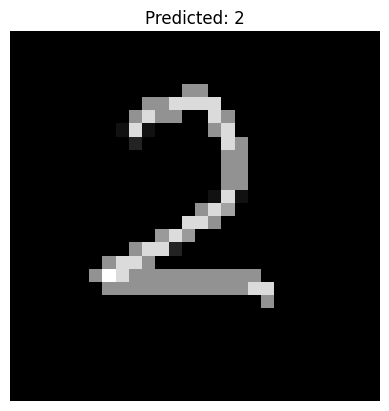

In [19]:
# Load image and pre-process identically to the training data
img       = Image.open('MNIST/test_img.png').convert('L')  # grayscale
img_array = np.invert(np.array(img))                       # invert (white digit on black)

print('Raw image shape:', img_array.shape)   # (28, 28)

# Flatten, normalise, and add batch dimension
test_image = img_array.ravel() / 255.0       # shape: (784,)
test_input = test_image[np.newaxis, :]       # shape: (1, 784) -- batch of 1

# Run inference
probabilities = loaded_model.predict(test_input, verbose=0)   # shape: (1, 10)
prediction    = np.argmax(probabilities, axis=1)[0]

print(f'Predicted class      : {prediction}')
print(f'Class probabilities  : {np.round(probabilities[0], 4)}')

# Show the image
plt.imshow(img_array, cmap='gray')
plt.title(f'Predicted: {prediction}')
plt.axis('off')
plt.show()

## 13 — (Optional) Convert to TensorFlow.js

Requires `tensorflowjs` to be installed: `pip install tensorflowjs`

In [20]:
# Uncomment the lines below if tensorflowjs is installed

# import tensorflowjs as tfjs
#
# tfjs.converters.save_keras_model(loaded_model, 'math_garden_stub/TFJS')
# print('Model converted to TensorFlow.js format and saved in math_garden_stub/TFJS/')

---
## 14 — Visualizations

A complete visual report of the dataset, training dynamics, and model performance.

| Plot | What it shows |
|---|---|
| 14.1 | Shared style + predictions cache |
| 14.2 | Class distribution bar chart |
| 14.3 | Sample digit grid (5 per class) |
| 14.4 | Training & validation accuracy/loss curves |
| 14.5 | Overfitting gap (train − val accuracy) |
| 14.6 | Confusion matrix heatmap |
| 14.7 | Per-class accuracy bar chart |
| 14.8 | Prediction grid with confidence bars |

### 14.1 — Style Configuration & Prediction Cache

In [21]:
# ── Shared dark-theme style ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#3a3d4d',
    'axes.labelcolor'  : '#e0e0e0',
    'axes.titlecolor'  : '#ffffff',
    'xtick.color'      : '#b0b0b0',
    'ytick.color'      : '#b0b0b0',
    'text.color'       : '#e0e0e0',
    'grid.color'       : '#2e3145',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
})

ACCENT   = '#7c83fd'   # blue-violet  (training curves)
ACCENT2  = '#f7b731'   # amber        (validation curves)
CORRECT  = '#2ecc71'   # green        (correct predictions)
WRONG    = '#e74c3c'   # red          (wrong predictions)

CLASS_NAMES = [str(i) for i in range(10)]

# ── Pre-compute test predictions once (reused by all plots) ──────────────────
y_pred_probs = model.predict(x_test, verbose=0)      # (10000, 10)
y_pred_int   = np.argmax(y_pred_probs, axis=1)       # (10000,)

print('Style configured. Predictions cached.')
print(f'Test accuracy from predictions: {(y_pred_int == y_test_int).mean():.2%}')

Style configured. Predictions cached.
Test accuracy from predictions: 98.01%


### 14.2 — Class Distribution (Training Set)

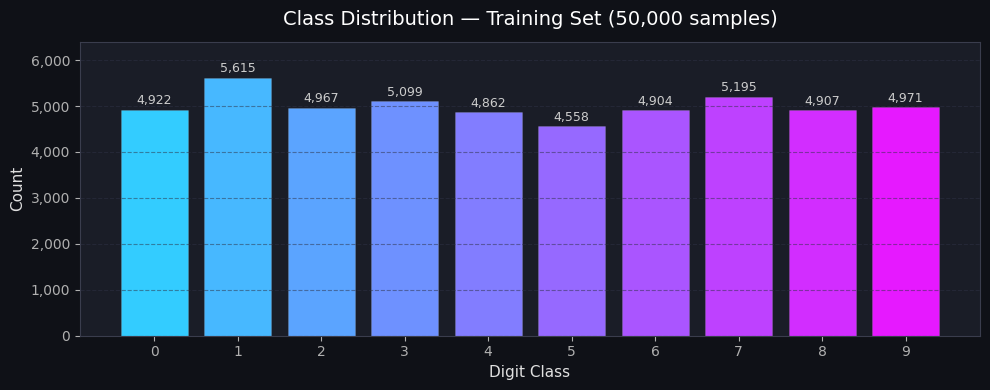

In [22]:
counts   = np.bincount(y_train_int, minlength=10)
gradient = plt.cm.cool(np.linspace(0.2, 0.9, 10))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, counts, color=gradient, edgecolor='#ffffff22', linewidth=0.6)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
            f'{cnt:,}', ha='center', va='bottom', fontsize=9, color='#cccccc')

ax.set_title('Class Distribution — Training Set (50,000 samples)', pad=12)
ax.set_xlabel('Digit Class')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, counts.max() * 1.14)
ax.grid(axis='y')
fig.tight_layout()
plt.show()

### 14.3 — Sample Digit Grid (5 Examples per Class)

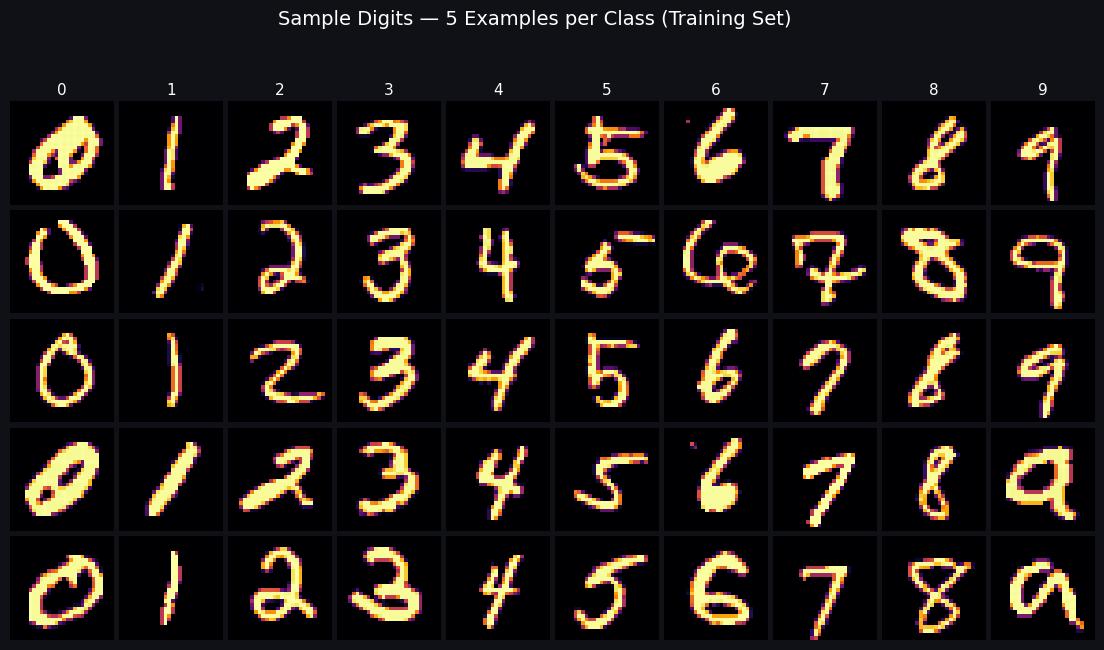

In [23]:
fig, axes = plt.subplots(5, 10, figsize=(14, 7),
                          facecolor='#0f1117',
                          gridspec_kw={'hspace': 0.05, 'wspace': 0.05})
fig.suptitle('Sample Digits — 5 Examples per Class (Training Set)',
             color='white', fontsize=14, y=1.01)

for digit in range(10):
    idxs = np.where(y_train_int == digit)[0][:5]
    for row, idx in enumerate(idxs):
        ax = axes[row, digit]
        ax.imshow(x_train[idx].reshape(28, 28), cmap='inferno', vmin=0, vmax=1)
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), color='white', fontsize=11, pad=4)

plt.show()

### 14.4 — Training History: Accuracy & Loss Side-by-Side

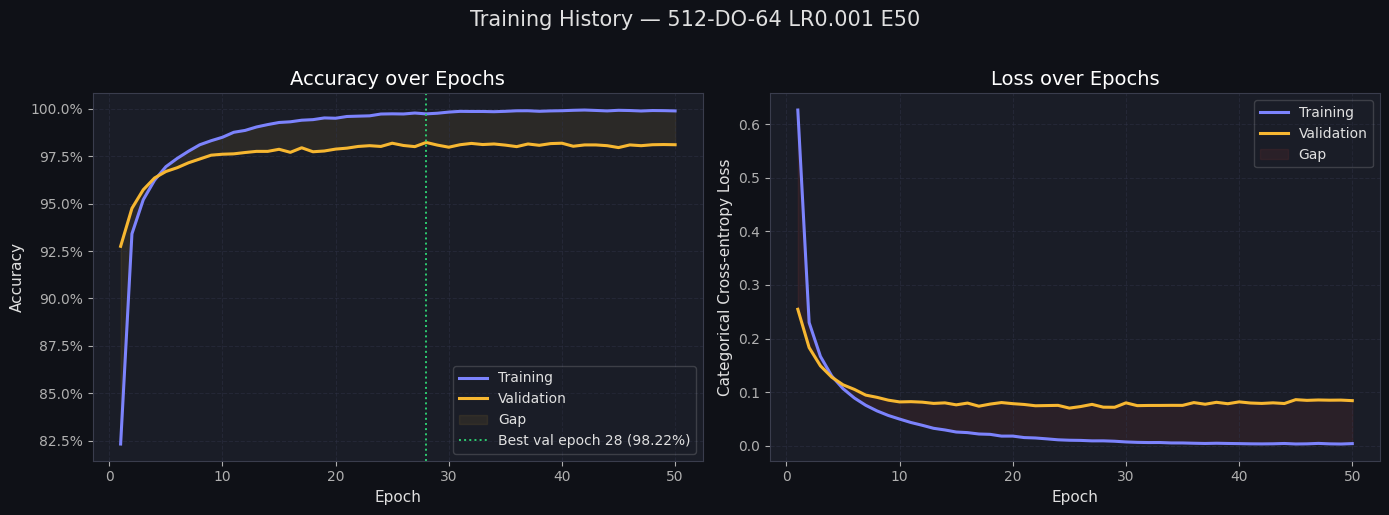

In [24]:
epochs_range = range(1, NR_EPOCHS + 1)
train_acc    = history.history['accuracy']
val_acc      = history.history['val_accuracy']
train_loss   = history.history['loss']
val_loss     = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ─────────────────────────────────────────────────────────────────
ax1.plot(epochs_range, train_acc, color=ACCENT,  linewidth=2.2, label='Training')
ax1.plot(epochs_range, val_acc,   color=ACCENT2, linewidth=2.2, label='Validation')
ax1.fill_between(epochs_range, train_acc, val_acc,
                 color=ACCENT2, alpha=0.08, label='Gap')
best_ep  = int(np.argmax(val_acc)) + 1
ax1.axvline(best_ep, color=CORRECT, linestyle=':', linewidth=1.4,
            label=f'Best val epoch {best_ep} ({max(val_acc):.2%})')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax1.legend(framealpha=0.2)
ax1.grid(True)

# ── Loss ─────────────────────────────────────────────────────────────────────
ax2.plot(epochs_range, train_loss, color=ACCENT,  linewidth=2.2, label='Training')
ax2.plot(epochs_range, val_loss,   color=ACCENT2, linewidth=2.2, label='Validation')
ax2.fill_between(epochs_range, train_loss, val_loss,
                 color=WRONG, alpha=0.08, label='Gap')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Categorical Cross-entropy Loss')
ax2.legend(framealpha=0.2)
ax2.grid(True)

fig.suptitle(f'Training History — {model_name}', fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

### 14.5 — Overfitting Gap (Train Accuracy minus Validation Accuracy)

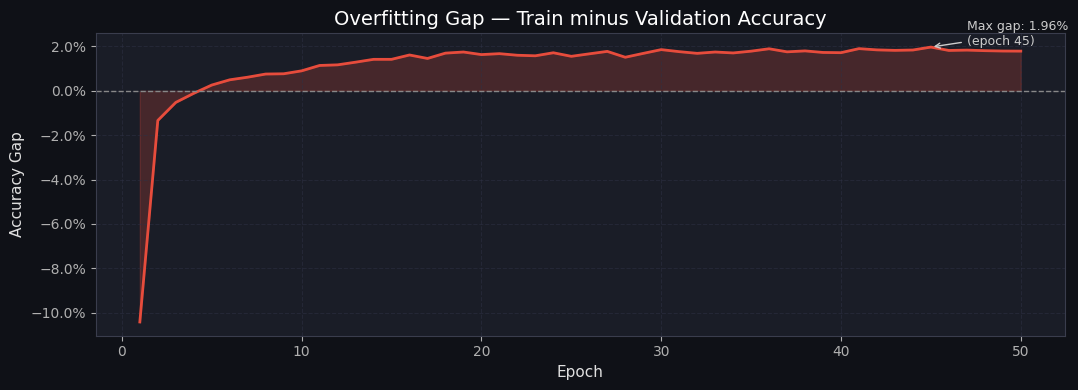

In [25]:
gap = [t - v for t, v in zip(train_acc, val_acc)]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(epochs_range, gap, color=WRONG, linewidth=2)
ax.fill_between(epochs_range, gap, alpha=0.22, color=WRONG)
ax.axhline(0, color='#888888', linewidth=1, linestyle='--')

# Annotate maximum gap
max_gap_ep = int(np.argmax(gap)) + 1
ax.annotate(f'Max gap: {max(gap):.2%}\n(epoch {max_gap_ep})',
            xy=(max_gap_ep, max(gap)),
            xytext=(max_gap_ep + 2, max(gap) * 1.05),
            arrowprops=dict(arrowstyle='->', color='#cccccc'),
            color='#cccccc', fontsize=9)

ax.set_title('Overfitting Gap — Train minus Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy Gap')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.grid(True)
fig.tight_layout()
plt.show()

### 14.6 — Confusion Matrix (Test Set)

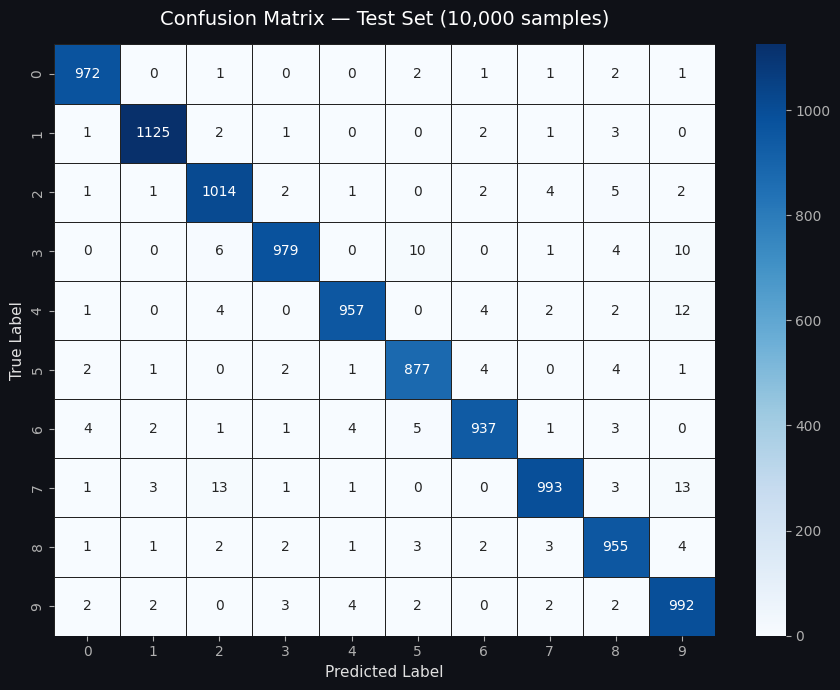

Total misclassified : 199 / 10000
Error rate          : 1.99%


In [26]:
cm = confusion_matrix(y_test_int, y_pred_int)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.4, linecolor='#222222',
    annot_kws={'size': 10},
    ax=ax,
)
ax.set_title('Confusion Matrix — Test Set (10,000 samples)', pad=14)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
fig.tight_layout()
plt.show()

# Summary
total_wrong = (y_pred_int != y_test_int).sum()
print(f'Total misclassified : {total_wrong} / {len(y_test_int)}')
print(f'Error rate          : {total_wrong / len(y_test_int):.2%}')

### 14.7 — Per-Class Accuracy (Test Set)

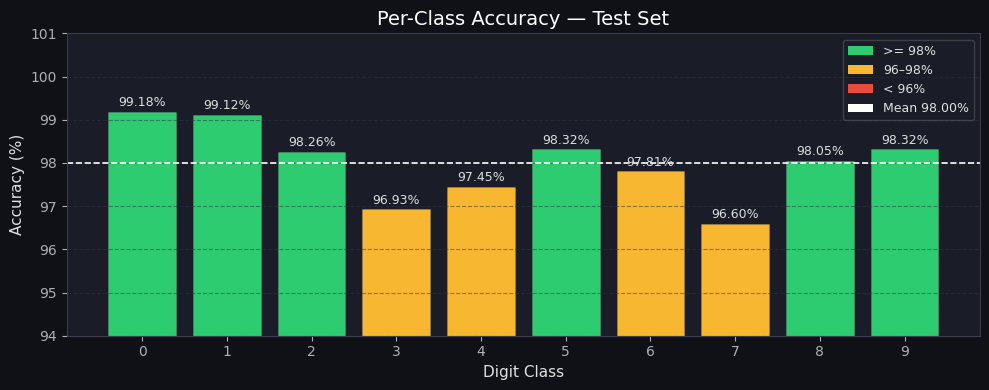

In [27]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)   # accuracy for each digit class

# Colour rule: green >= 98%, amber >= 96%, red below 96%
colors = [CORRECT if a >= 0.98 else ACCENT2 if a >= 0.96 else WRONG
          for a in per_class_acc]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASS_NAMES, per_class_acc * 100,
              color=colors, edgecolor='#ffffff22', linewidth=0.6)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.06,
            f'{acc:.2%}', ha='center', va='bottom', fontsize=9, color='#dddddd')

mean_acc = per_class_acc.mean()
ax.axhline(mean_acc * 100, color='white', linestyle='--', linewidth=1.2,
           label=f'Mean {mean_acc:.2%}')

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=CORRECT,  label='>= 98%'),
    Patch(facecolor=ACCENT2,  label='96–98%'),
    Patch(facecolor=WRONG,    label='< 96%'),
    Patch(facecolor='white',  label=f'Mean {mean_acc:.2%}'),
]
ax.legend(handles=legend_elements, framealpha=0.2, fontsize=9)

ax.set_title('Per-Class Accuracy — Test Set')
ax.set_xlabel('Digit Class')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(94, 101)
ax.grid(axis='y')
fig.tight_layout()
plt.show()

### 14.8 — Prediction Grid with Confidence Bars (25 Random Test Samples)

Each pair of subplots shows the digit image (left) and its class probability distribution (right).  
**Green** border = correct prediction, **Red** border = wrong prediction.

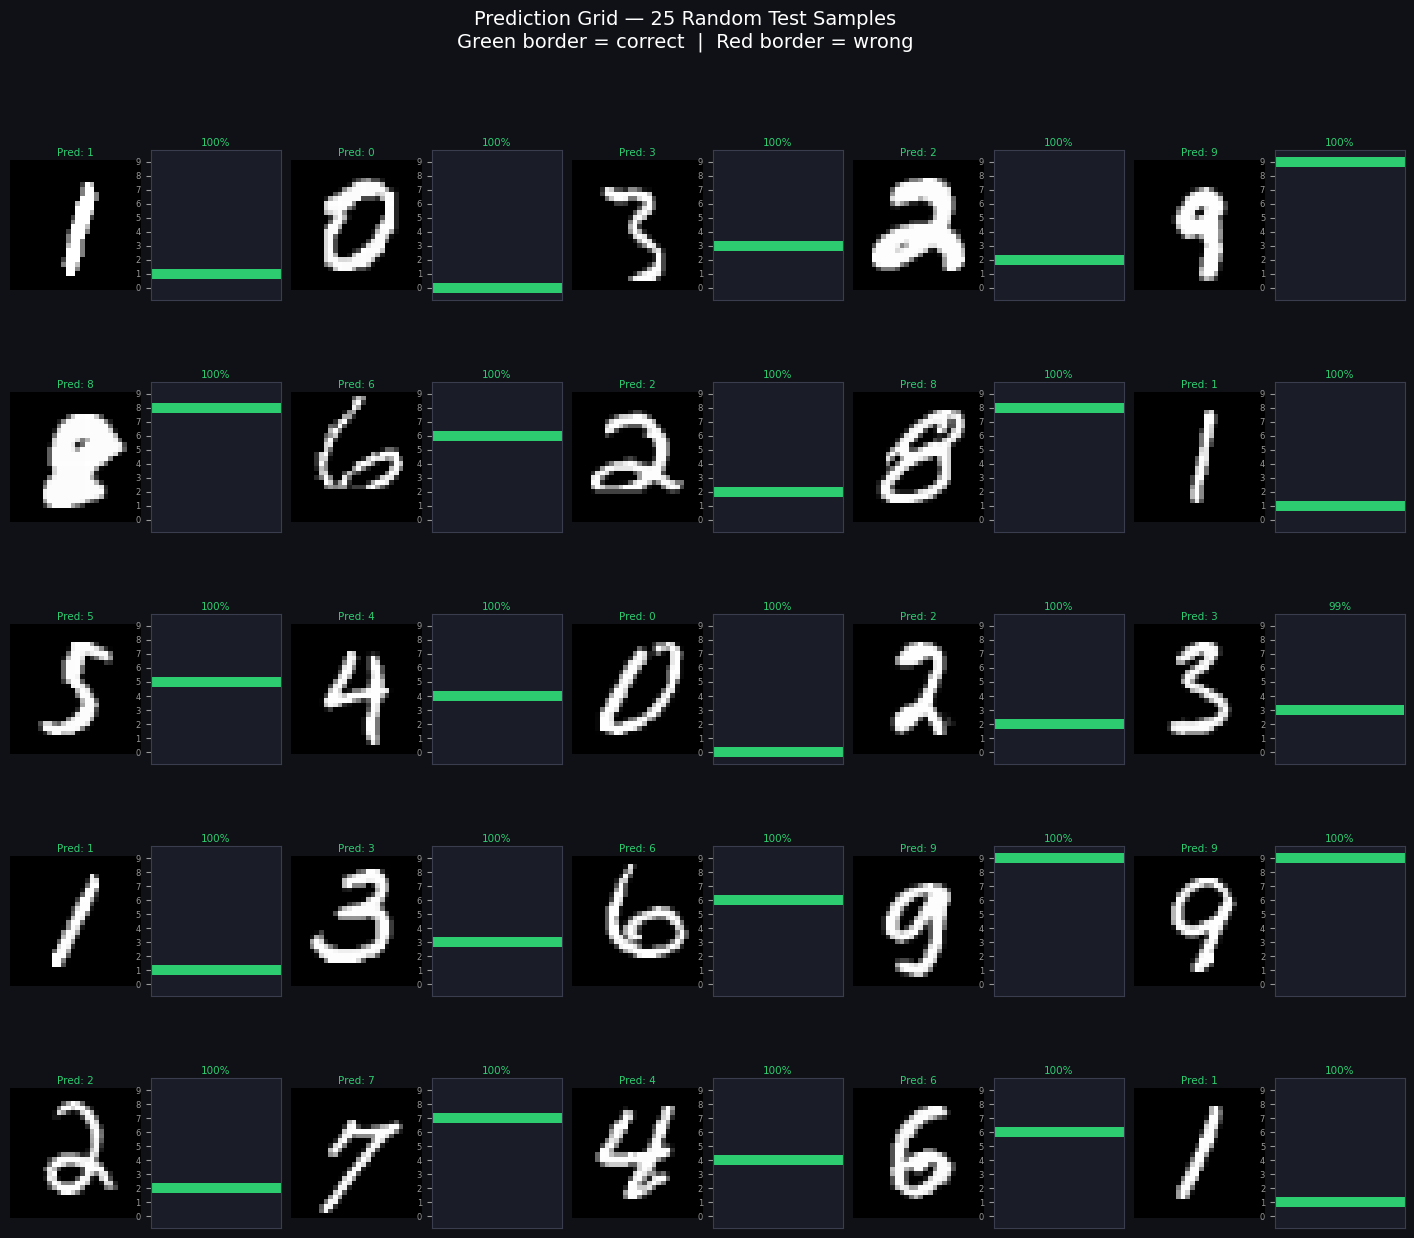

In [28]:
rng        = np.random.default_rng(42)
sample_idx = rng.choice(len(x_test), 25, replace=False)

COLS = 5   # number of digit+bar column pairs
ROWS = 5

fig, axes = plt.subplots(
    ROWS, COLS * 2,
    figsize=(18, 14),
    facecolor='#0f1117',
    gridspec_kw={'wspace': 0.08, 'hspace': 0.55},
)
fig.suptitle(
    'Prediction Grid — 25 Random Test Samples\n'
    'Green border = correct  |  Red border = wrong',
    color='white', fontsize=14,
)

for plot_i, idx in enumerate(sample_idx):
    row        = plot_i // COLS
    col_pair   = plot_i %  COLS
    true_label = y_test_int[idx]
    pred_label = y_pred_int[idx]
    probs      = y_pred_probs[idx]          # (10,)
    correct    = true_label == pred_label
    border     = CORRECT if correct else WRONG

    # ── Image subplot ──────────────────────────────────────────────────────────
    ax_img = axes[row, col_pair * 2]
    ax_img.imshow(x_test[idx].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    ax_img.axis('off')
    for spine in ax_img.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(border)
        spine.set_linewidth(2.5)
    if correct:
        title_txt = f'Pred: {pred_label}'
    else:
        title_txt = f'Pred:{pred_label} True:{true_label}'
    ax_img.set_title(title_txt, color=border, fontsize=7.5, pad=3)

    # ── Confidence bar subplot ─────────────────────────────────────────────────
    ax_bar = axes[row, col_pair * 2 + 1]
    bar_colors = [
        CORRECT if i == true_label else
        WRONG   if i == pred_label else '#444444'
        for i in range(10)
    ]
    ax_bar.barh(CLASS_NAMES, probs, color=bar_colors, edgecolor='none', height=0.72)
    ax_bar.set_xlim(0, 1)
    ax_bar.set_facecolor('#1a1d27')
    ax_bar.tick_params(axis='y', labelsize=6, colors='#999')
    ax_bar.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax_bar.set_title(f'{probs[pred_label]:.0%}', fontsize=7.5,
                     color=border, pad=3)

plt.show()